# Basic Olivetti Faces Generation from Noise using UNet Architecture

This program demonstrates a straightforward approach to generating Olivetti faces from Gaussian noise. By applying the flow model, we can produce clear and recognizable face images directly from noise.




In [1]:
import os
import torch
from torch import nn, Tensor
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.datasets import fetch_olivetti_faces

Configuration

In [2]:
# Hyperparameters
batch_size = 64

# 1. Load the dataset
data = fetch_olivetti_faces(shuffle=True)
images = data.images  # (400, 64, 64), float32, between 0 and 1
targets = data.target  # (400,)

# 2. Convert to PyTorch tensor
images_tensor = torch.tensor(images).unsqueeze(1)  # (N, 1, 64, 64)
targets_tensor = torch.tensor(targets)

# 3. Create a dataset and a loader
dataset = TensorDataset(images_tensor, targets_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


Flow Model

In [5]:
# A double convolutional block: Conv2d -> GroupNorm -> SiLU -> Conv2d -> GroupNorm -> SiLU
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),  # First 3x3 convolution
            nn.GroupNorm(4, out_ch),  # Normalization over groups
            nn.SiLU(),  # Non-linear activation (Sigmoid-weighted Linear Unit)
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),  # Second 3x3 convolution
            nn.GroupNorm(4, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        return self.block(x)  # Pass input through the double conv block

# Downsampling block: MaxPool followed by DoubleConv
class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)  # Downsample by a factor of 2
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))  # Apply pooling then conv

# Upsampling block: ConvTranspose2d + skip connection + DoubleConv
class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)  # Upsample by factor of 2
        self.conv = DoubleConv(in_ch, out_ch)  # Note: in_ch from concatenation

    def forward(self, x1, x2):
        x1 = self.up(x1)  # Upsample lower-resolution feature map

        # Compute padding sizes in case upsampled size doesn't match skip connection
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])  # Pad to match dimensions

        x = torch.cat([x2, x1], dim=1)  # Concatenate along channel dimension (skip connection)
        return self.conv(x)  # Apply double conv on merged feature maps

# Full U-Net architecture with a time-dependent embedding
class UNetFlow(nn.Module):
    def __init__(self, image_size=64):
        super().__init__()
        self.image_size = image_size
        self.t_proj = nn.Linear(1, image_size * image_size)
        self.inc = DoubleConv(1 + 1, 32)  # Changed from 3+1 to 1+1 for grayscale images
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.up1 = Up(128, 64)
        self.up2 = Up(64, 32)
        self.outc = nn.Conv2d(32, 1, kernel_size=1)  # Changed from 3 to 1 for grayscale output

    def forward(self, x_t: Tensor, t: Tensor) -> Tensor:
        B = x_t.size(0)
        t_img = self.t_proj(t.view(B, 1)).view(B, 1, self.image_size, self.image_size)
        x = torch.cat([x_t, t_img], dim=1)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x = self.up1(x3, x2)
        x = self.up2(x, x1)
        return self.outc(x)

    def step(self, x_t, t_start, t_end):
        return x_t + (t_end - t_start) * self(
            x_t + self(x_t, t_start) * (t_end - t_start) / 2,
            (t_start + t_end) / 2
        )

Training

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
flow = UNetFlow().to(device)  # Create model on device
optimizer = torch.optim.AdamW(flow.parameters(), lr=1e-3)  # Optimizer
loss_fn = nn.MSELoss()  # Loss function

for epoch in range(500):
    for x_1, _ in loader:
        x_1 = x_1.to(device)  # Target images (shape: [B, 3, H, W])
        x_0 = torch.randn_like(x_1)  # Noise images
        t = torch.rand(x_1.size(0), 1).to(device)  # Random time
        x_t = (1 - t.view(-1, 1, 1, 1)) * x_0 + t.view(-1, 1, 1, 1) * x_1
        dx_t = x_1 - x_0

        optimizer.zero_grad()
        loss = loss_fn(flow(x_t, t), dx_t)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.7162
Epoch 2, Loss: 0.2988
Epoch 3, Loss: 0.1518
Epoch 4, Loss: 0.2341
Epoch 5, Loss: 0.0975
Epoch 6, Loss: 0.2245
Epoch 7, Loss: 0.1305
Epoch 8, Loss: 0.1223
Epoch 9, Loss: 0.1815
Epoch 10, Loss: 0.1732
Epoch 11, Loss: 0.0969
Epoch 12, Loss: 0.1132
Epoch 13, Loss: 0.0991
Epoch 14, Loss: 0.1379
Epoch 15, Loss: 0.1043
Epoch 16, Loss: 0.1031
Epoch 17, Loss: 0.0721
Epoch 18, Loss: 0.0864
Epoch 19, Loss: 0.1412
Epoch 20, Loss: 0.1344
Epoch 21, Loss: 0.0777
Epoch 22, Loss: 0.1309
Epoch 23, Loss: 0.0927
Epoch 24, Loss: 0.0818
Epoch 25, Loss: 0.0826
Epoch 26, Loss: 0.1355
Epoch 27, Loss: 0.0755
Epoch 28, Loss: 0.1390
Epoch 29, Loss: 0.0730
Epoch 30, Loss: 0.1054
Epoch 31, Loss: 0.0712
Epoch 32, Loss: 0.1863
Epoch 33, Loss: 0.1251
Epoch 34, Loss: 0.0736
Epoch 35, Loss: 0.0788
Epoch 36, Loss: 0.0707
Epoch 37, Loss: 0.0532
Epoch 38, Loss: 0.0783
Epoch 39, Loss: 0.0450
Epoch 40, Loss: 0.0793
Epoch 41, Loss: 0.1101
Epoch 42, Loss: 0.0840
Epoch 43, Loss: 0.1285
Epoch 44, Loss: 0.07

Sampling and Visualization

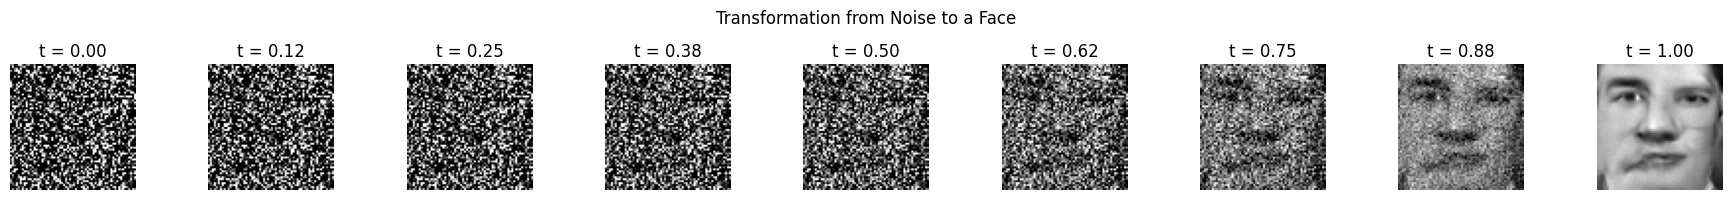

In [26]:
x = torch.randn(1, 1, flow.image_size, flow.image_size).to(device) # Changed 3 to 1 for grayscale and accessed image_size from the flow model
n_steps = 8
time_steps = torch.linspace(0, 1.0, n_steps + 1).to(device)

trajectory = [x.clone()]
with torch.no_grad():
    for i in range(n_steps):
        x = flow.step(x, time_steps[i], time_steps[i + 1])
        trajectory.append(x.clone())

fig, axes = plt.subplots(1, n_steps + 1, figsize=(2*(n_steps+1), 2))
for i, x_i in enumerate(trajectory):
    img = x_i.squeeze().cpu().clamp(0, 1).numpy()  # Removed permute as it's not needed for grayscale
    axes[i].imshow(img, cmap='gray') # Added cmap='gray' for better visualization
    axes[i].set_title(f"t = {time_steps[i]:.2f}")
    axes[i].axis('off')

plt.suptitle("Transformation from Noise to a Face")
plt.tight_layout()
plt.show()

# Save the model
os.makedirs('save', exist_ok=True)  # Make sure save folder exists
torch.save(flow.state_dict(), 'save/unet_flow_mnist.pth')  # Save model weights